<a href="https://colab.research.google.com/github/aaayseee/yzta-bootcamp/blob/main/YZTA_Churn_Tahmin_Modeli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

# Ortak Drive klasörünün içindeki Excel dosyasının yolu
dosya_yolu = '/content/drive/MyDrive/YZTA_Churn_Projesi/E Commerce Dataset.xlsx'

# Excel dosyasını veri çerçevesine (DataFrame) aktarıyoruz
df = pd.read_excel(dosya_yolu)

# Verinin ilk 5 satırını ekranda gösteriyoruz
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Data,Variable,Discerption
1,NaN,E Comm,CustomerID,Unique customer ID
2,NaN,E Comm,Churn,Churn Flag
3,NaN,E Comm,Tenure,Tenure of customer in organization
4,NaN,E Comm,PreferredLoginDevice,Preferred login device of customer


In [ ]:
import pandas as pd

# Excel dosyasının yolu
dosya_yolu = '/content/drive/MyDrive/YZTA_Churn_Projesi/E Commerce Dataset.xlsx'

# sheet_name=1 diyerek Excel'deki 2. sayfayı (asıl verinin olduğu kısmı) okumasını söylüyoruz
df = pd.read_excel(dosya_yolu, sheet_name=1)

# Verinin ilk 5 satırını ekranda gösteriyoruz
df.head()


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [ ]:
df.info()
df.isnull().sum()
df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

,count
Churn,
0,4682
1,948


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


In [ ]:
# Sayısal sütunları tespit edip boşlukları medyan değerleriyle dolduruyoruz
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Temizlik başarılı oldu mu diye son bir kontrol yapıyoruz
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,0
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,0
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,0
NumberOfDeviceRegistered,0


In [ ]:
# Metin içeren tüm sütunları bulup içindeki benzersiz (unique) değerleri listeliyoruz
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col} Sütunu Değerleri:")
    print(df[col].unique())
    print("-" * 40)

PreferredLoginDevice Sütunu Değerleri:
['Mobile Phone' 'Phone' 'Computer']
----------------------------------------
PreferredPaymentMode Sütunu Değerleri:
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
----------------------------------------
Gender Sütunu Değerleri:
['Female' 'Male']
----------------------------------------
PreferedOrderCat Sütunu Değerleri:
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
----------------------------------------
MaritalStatus Sütunu Değerleri:
['Single' 'Divorced' 'Married']
----------------------------------------


In [ ]:
# Aynı anlama gelen kelimeleri tek bir standart kelimeye dönüştürüyoruz
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace('Phone', 'Mobile Phone')
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({'CC': 'Credit Card', 'COD': 'Cash on Delivery'})
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')

# Değişikliklerin işe yarayıp yaramadığını hızlıca kontrol edelim
print("Login Cihazları:", df['PreferredLoginDevice'].unique())
print("Ödeme Yöntemleri:", df['PreferredPaymentMode'].unique())
print("Sipariş Kategorileri:", df['PreferedOrderCat'].unique())

Login Cihazları: ['Mobile Phone' 'Computer']
Ödeme Yöntemleri: ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet']
Sipariş Kategorileri: ['Laptop & Accessory' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']


### 🛠️ Veri Temizliği ve Tekilleştirme (Kategorik Veri Düzenleme)

Modelin eğitimi sırasında yapay zekanın kafasının karışmaması için metin tabanlı (kategorik) sütunlardaki benzersiz değerleri inceledik ve aynı anlama gelen mükerrer verileri standart hale getirdik:

* **PreferredLoginDevice:** `Phone` ve `Mobile Phone` ifadelerini `Mobile Phone` altında birleştirdik.
* **PreferredPaymentMode:** Kısaltma olan `CC`'yi `Credit Card`, `COD`'yi ise `Cash on Delivery` olarak güncelledik.
* **PreferedOrderCat:** `Mobile` kategorisini `Mobile Phone` ile tekilleştirdik.

Böylece verimiz modelleme ve analiz süreci için tamamen tutarlı hale geldi.

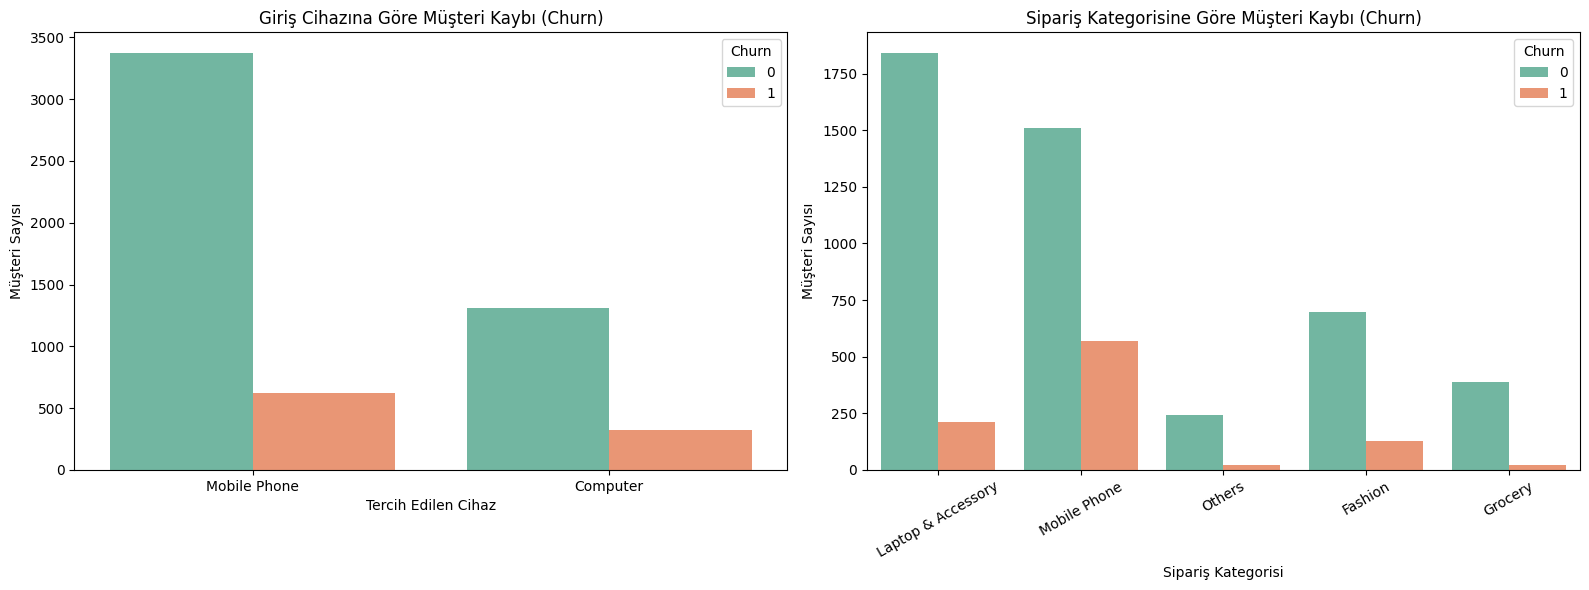

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin genel boyutunu belirliyoruz
plt.figure(figsize=(16, 6))

# 1. Grafik: Giriş Cihazına Göre Churn Durumu
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='PreferredLoginDevice', hue='Churn', palette='Set2')
plt.title('Giriş Cihazına Göre Müşteri Kaybı (Churn)')
plt.xlabel('Tercih Edilen Cihaz')
plt.ylabel('Müşteri Sayısı')

# 2. Grafik: Alışveriş Kategorisine Göre Churn Durumu
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='PreferedOrderCat', hue='Churn', palette='Set2')
plt.title('Sipariş Kategorisine Göre Müşteri Kaybı (Churn)')
plt.xlabel('Sipariş Kategorisi')
plt.ylabel('Müşteri Sayısı')
plt.xticks(rotation=30) # Yazılar birbirine binmesin diye eğik yazdırıyoruz

# Grafikleri ekrana düzgünce yerleştir ve göster
plt.tight_layout()
plt.show()

### 📊 EDA Sonuçları ve İş İçgörüleri (Business Insights)

Yukarıdaki grafiklerde müşterilerimizin sistemi terk etme (Churn) davranışlarını görselleştirdik. Çıkan en kritik iki sonuç şudur:

* **Giriş Cihazı Analizi:** Müşterilerimizin büyük çoğunluğu platforma 'Mobile Phone' (Cep Telefonu) üzerinden giriş yapıyor. Her iki cihazda da churn oranları mevcut olsa da, asıl dramatik fark sipariş kategorilerinde yatıyor.
* **Sipariş Kategorisi Analizi (Kritik Bulgu):** 'Mobile Phone' (Cep Telefonu) kategorisinden alışveriş yapan müşterilerin platformu terk etme oranı (turuncu bar) diğer tüm kategorilere göre olağanüstü yüksek! Buna karşılık 'Laptop & Accessory' (Bilgisayar ve Aksesuar) ile 'Grocery' (Market) müşterileri platforma çok daha sadık.

**💡 Aksiyon Önerisi (Jüri/Yönetim İçin):** Şirketin en çok kayıp yaşadığı alan 'Mobile Phone' kategorisinden alışveriş yapan müşterilerdir. Bu segmentteki müşterileri elde tutmak (retention) için özel indirimler, sadakat programları veya hatırlatıcı kampanyalar kurgulanması gerektiği açıkça görülmektedir.


In [ ]:
# Tüm metin (kategorik) verilerini makinenin anlayabileceği formata (1 ve 0'lara) çeviriyoruz
df_encoded = pd.get_dummies(df, drop_first=True)

# Dönüşümden sonra verimizin yeni haline (ilk 5 satıra) bakalım
df_encoded.head()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,50001,1,4.0,3,6.0,3.0,3,2,9,1,...,True,False,False,False,False,True,False,False,False,True
1,50002,1,9.0,1,8.0,3.0,4,3,7,1,...,False,False,True,True,False,False,True,False,False,True
2,50003,1,9.0,1,30.0,2.0,4,3,6,1,...,True,False,False,True,False,False,True,False,False,True
3,50004,1,0.0,3,15.0,2.0,4,5,8,0,...,True,False,False,True,False,True,False,False,False,True
4,50005,1,0.0,1,12.0,3.0,3,5,3,0,...,False,False,False,True,False,False,True,False,False,True


### ⚙️ Veri Dönüşümü (One-Hot Encoding)

Makine öğrenmesi algoritmaları metin tabanlı (kategorik) verileri doğrudan işleyemediği için bu değerleri algoritmaların anlayabileceği matematiksel bir formata (1 ve 0'lara) çevirmemiz gerekiyordu.

* Pandas'ın `get_dummies` fonksiyonu ile One-Hot Encoding işlemini uyguladık.
* "Dummy Variable Trap" (Kukla Değişken Tuzağı) problemine düşmemek ve makinenin kafasını karıştırmamak için `drop_first=True` parametresini kullanarak gereksiz tekrarları sildik.

Bu aşamayla birlikte verimiz, makine öğrenmesi modelini eğitmeye %100 hazır hale gelmiştir.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Hedef (y) ve Özellikleri (X) Ayırma
# CustomerID sadece bir sıra numarasıdır, makineyi yanıltmasın diye çıkarıyoruz.
X = df_encoded.drop(['Churn', 'CustomerID'], axis=1)
y = df_encoded['Churn']

# 2. Veriyi Eğitim (%80) ve Test (%20) Olarak Bölme
# random_state=42 yazıyoruz ki her çalıştırdığımızda aynı rastgele dağılımı yapsın, sonuçlar değişmesin.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Modeli Kurma ve Eğitme
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 4. Modeli Sınava Sokma (Tahmin Yaptırma)
y_pred = rf_model.predict(X_test)

# Sonuç Karnesini Ekrana Yazdırma
print("Modelin Genel Doğruluk Oranı (Accuracy):", accuracy_score(y_test, y_pred))
print("\n--- Detaylı Karne (Classification Report) ---")
print(classification_report(y_test, y_pred))

Modelin Genel Doğruluk Oranı (Accuracy): 0.9742451154529307

--- Detaylı Karne (Classification Report) ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       941
           1       0.98      0.86      0.92       185

    accuracy                           0.97      1126
   macro avg       0.98      0.93      0.95      1126
weighted avg       0.97      0.97      0.97      1126



### 🎯 Makine Öğrenmesi Model Sonuçları ve Değerlendirme

Veri setimiz üzerinde **Random Forest (Rastgele Orman)** algoritmasını kullanarak müşterilerimizin churn (terk etme) durumlarını tahmin eden modelimizi eğittik. Ortaya çıkan test sonuçları oldukça başarılıdır:

* **Genel Doğruluk Oranı (Accuracy): %97.4** - Modelimiz, daha önce hiç görmediği test verisindeki müşterilerin %97.4'ünün davranışını doğru tahmin etmiştir.
* **Precision (Hassasiyet): %98** - Modelimizin "Sistemi terk edecek" olarak işaretlediği müşterilerin %98'i gerçekten sistemi terk eden kişilerden oluşmaktadır. Yanlış alarm oranımız (False Positive) yok denecek kadar azdır.
* **Recall (Duyarlılık): %86** - Gerçekte sistemi terk eden (Churn = 1) müşterilerin %86'sı modelimiz tarafından başarıyla tespit edilmiştir.

**Sonuç:** Modelimiz, özellikle sistemi terk etme eğiliminde olan riskli müşterileri yüksek bir hassasiyetle yakalamaktadır. Bu tahminler doğrultusunda müşteri tutundurma (retention) kampanyaları çok daha hedefli ve düşük maliyetli şekilde yönetilebilir.
